# Figure 3b, 3c, 3d and Figure S3f, S3g — lamina I projection neurons

Panels 3b, 3c, 3d and the two S3 supplements, from two shipped tables plus the SWC listing
used to order the neurons. **Runs offline — no CAVE access.** Panel 3a is skeleton
renderings.

| Panel | Content |
| --- | --- |
| **S3g** | UMAP + HDBSCAN of the 40 P2 neurons on sensory input features — the clustering that *defines* the P2 subtypes |
| **3b** | Violin: sensory as a fraction of total synaptic input, by PN subtype |
| **3c** | Tri-axis scatter: absolute drive from the three afferent classes that reach PNs |
| **3d** | Per-PN heatmap: fraction of sensory input from each afferent subtype |
| **S3f** | The same heatmap on raw synapse counts (log scale) |

### Where the labels come from — read this before changing anything

PN subtypes are **the output of the clustering in this notebook**, not an input.
`projection_neuron.csv` carries a `cell_type` column, but it is the *pre-curation*
grouping (p1 6, p2_poly 18, p2_noci 14, p2_cold 8) and does **not** match the published
*n* values. The clustering reassigns five neurons, giving the final
**P1 6, P2-Cold 9, P2-Noci 16, P2-Poly 15** — which is what the legend reports and what the
CAVE table `spinalcord_neuron_clusters_2` contains.

Verified against CAVE at materialization 669: the HDBSCAN clusters map one-to-one onto the
CAVE labels (cluster 0 → `p2_cold` ×9, 1 → `p2_noci` ×16, 2 → `p2_poly` ×15, a clean
diagonal), while the CSV's `cell_type` disagrees with CAVE for 5 of 46 neurons. So: use the
clusters, not the CSV column.

### Row order is load-bearing

UMAP output depends on the order of its input rows. The original took that order from an
*unsorted* glob of the SWC folders — filesystem order, which differs between machines and
is not reproducible. `pn_preclustering_order.csv` records the exact order that reproduces
the published clustering, and the notebook reads that instead.

The folders it refers to, `data/swc_skeletons_pn_preclustering/`, hold the **pre**-clustering
grouping: they are this analysis's input, whereas `data/swc_skeletons/` holds the
post-curation grouping, its output. Both order and folder set matter — CSV order gives two
clusters instead of three, and sorted order gives five. The notebook asserts an exact match
against the shipped reference so neither can regress silently.

Only the SWC *filenames* are read, for ordering. The original also dropped any skeleton
with zero dendrite length; all 46 pass, so that filter is a no-op here and the file
contents are not needed.

In [11]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "svg.fonttype": "none",
    "font.size": 6,
})
CM = 1 / 2.54


In [12]:
from pathlib import Path

import numpy as np
import pandas as pd

DATA = Path("../data")
SENSORY_CSV = DATA / "sensory_input_features/projection_neuron.csv"
SWC_PRECLUSTER = DATA / "swc_skeletons_pn_preclustering"
REFERENCE_CLUSTERS = DATA / "sensory_input_features/pn_p2_hdbscan_clusters.csv"
ORDER_CSV = DATA / "sensory_input_features/pn_preclustering_order.csv"

# Folder order fixes the row order handed to UMAP -- see the note above.
FOLDERS = ["p1", "p2_poly", "p2_noci", "p2_cold"]

# `Aδ-HTMR + C-Heat` merges Aδ-HTMR with peptidergic C-fibres into one nociceptor
# category, "to emphasize selectivity for nociceptive drive" (Methods).
FEATURE_COLUMNS = ["Aδ-HTMR + C-Heat", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic",
                   "N/A", "Aβ-LTMR", "Aδ-LTMR", "C-LTMR", "low_confidence_sensory"]

sens = pd.read_csv(SENSORY_CSV, index_col=0)
sens.index = sens.index.astype(str)
sens.columns = [c.strip() for c in sens.columns]

# Row order and the pre-clustering grouping.
#
# UMAP's output depends on the order of its input rows, and the original took that
# order from an unsorted directory glob -- i.e. filesystem order, which is not
# portable. pn_preclustering_order.csv records the exact order that reproduces the
# published clustering, so the result no longer depends on how a filesystem happens
# to enumerate files. The SWCs themselves ship in swc_skeletons_pn_preclustering/;
# only the ordering is read here.
order = pd.read_csv(ORDER_CSV)
swc_ids = [str(i) for i in order.neuron_id]
y4 = pd.Series(dict(zip(swc_ids, order.preclustering_group)),
               name="preclustering_group").astype(str)

missing = [i for i in swc_ids
           if not any((SWC_PRECLUSTER / f / f"{i}.swc").exists() for f in FOLDERS)]
if missing:
    raise FileNotFoundError(f"{len(missing)} SWC file(s) missing: {missing[:5]}")
counts = sens[FEATURE_COLUMNS].astype(float).fillna(0.0)

common = pd.Index(swc_ids).intersection(counts.index).intersection(y4.index)
counts, y4 = counts.loc[common], y4.loc[common]

print(f"{len(common)} PNs aligned (SWC ∩ sensory table)")
print(y4.value_counts().reindex(FOLDERS).to_string())


46 PNs aligned (SWC ∩ sensory table)
preclustering_group
p1          6
p2_poly    18
p2_noci    14
p2_cold     8


In [13]:
# Sensory feature matrix: per-subtype fractions (CNS column dropped), log1p counts,
# and the CNS fraction. Raw counts are deliberately excluded.
row_sums = counts.sum(axis=1).replace(0.0, np.nan)

fractions = counts.div(row_sums, axis=0).fillna(0.0).drop(columns=["N/A"])
fractions.columns = [f"sens_frac__{c}" for c in fractions.columns]

log_counts = np.log1p(counts)
log_counts.columns = [f"sens_log1p__{c}" for c in log_counts.columns]

cns_fraction = (counts["N/A"] / row_sums).fillna(0.0).rename("cns_fraction").to_frame()

X_sens = pd.concat([fractions, log_counts, cns_fraction], axis=1)
print(f"sensory feature matrix: {X_sens.shape[0]} neurons x {X_sens.shape[1]} features")


sensory feature matrix: 46 neurons x 18 features


## Figure S3g — UMAP + HDBSCAN of the P2 neurons

P1 is excluded: it was set aside on morphology (ventrally directed dendrites into the LTMR
recipient zone) before any clustering, and receives almost no direct sensory input. The
remaining 40 P2 neurons are clustered on sensory input alone — PNs are often truncated at
the volume boundary, so morphology features are unreliable for them (Methods).

In [14]:
import hdbscan
from sklearn.preprocessing import StandardScaler
from umap import UMAP

N_NEIGHBORS, MIN_DIST, RANDOM_STATE = 4, 0.2, 42
MIN_CLUSTER_SIZE, CLUSTER_SELECTION = 7, "leaf"

P2_GROUPS = ["p2_cold", "p2_poly", "p2_noci"]
X_p2 = X_sens.loc[y4.isin(P2_GROUPS)]
print(f"{len(X_p2)} P2 neurons entering the embedding")

embedding = UMAP(n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, n_components=2,
                 metric="euclidean", random_state=RANDOM_STATE).fit_transform(
    StandardScaler().fit_transform(X_p2.to_numpy(float)))

labels = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=1,
                         cluster_selection_method=CLUSTER_SELECTION,
                         metric="euclidean").fit_predict(embedding)

clusters = pd.Series(labels, index=X_p2.index.astype(np.int64), name="hdbscan_cluster")
print(clusters.value_counts().sort_index().to_string())


40 P2 neurons entering the embedding
hdbscan_cluster
0     9
1    16
2    15


/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/wangchu/opt/anaconda3/envs/cave310/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [15]:
# The clustering must match the published assignment exactly.
from sklearn.metrics import adjusted_rand_score

reference = pd.read_csv(REFERENCE_CLUSTERS).set_index("neuron_id")["hdbscan_cluster"]
joined = pd.concat([clusters, reference.rename("reference")], axis=1).dropna()

ari = adjusted_rand_score(joined.hdbscan_cluster, joined.reference)
print(pd.crosstab(joined.hdbscan_cluster, joined.reference).to_string())
print(f"\nARI vs the published clustering: {ari:.4f}")
assert ari == 1.0, "clustering does not reproduce the published assignment"
assert (joined.hdbscan_cluster == joined.reference).all(), "cluster numbering differs"
print("exact match, including cluster numbering")


reference        0   1   2
hdbscan_cluster           
0                9   0   0
1                0  16   0
2                0   0  15

ARI vs the published clustering: 1.0000
exact match, including cluster numbering


### The S3g panel

Scatter of the embedding coloured by HDBSCAN cluster, with a round-dotted convex hull
around each. Ported from the original plotting cell; the cluster colours and legend labels
are the published ones.

In [16]:
# The ported plotting cell expects these two names.
emb3 = pd.DataFrame(embedding, index=X_p2.index, columns=["UMAP1", "UMAP2"])
cl_hdb = pd.Series(labels, index=X_p2.index, name="hdbscan_cluster")


Saved: figureS3g_pn_umap_hdbscan.svg


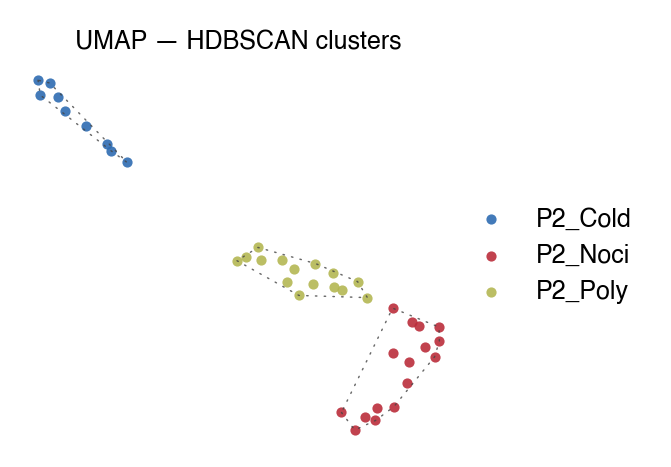

In [17]:
# === Plot UMAP with HDBSCAN cluster colors (custom palette) + round-dotted cluster outlines ===
# Update requested:
#   cluster 0 -> #2e6cb2  (P2_Cold)
#   cluster 1 -> #bb2d3b  (P2_Noci)   <-- swapped with cluster 2
#   cluster 2 -> #b4b753  (P2_Poly)
# Figure size: 6 cm x 4 cm
# Legend labels: Cluster 0: P2_Cold, Cluster 1: P2_Noci, Cluster 2: P2_Poly

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
})

# Assumes you have:
#   emb3: DataFrame with UMAP1/UMAP2
#   cl_hdb: Series of HDBSCAN cluster IDs aligned to emb3.index
assert isinstance(emb3, pd.DataFrame) and {"UMAP1","UMAP2"}.issubset(emb3.columns)
assert isinstance(cl_hdb, pd.Series)

emb_use = emb3.loc[emb3.index.intersection(cl_hdb.index)].copy()
cl_use  = cl_hdb.loc[emb_use.index].copy()

def _cm_to_inches(w_cm: float, h_cm: float):
    return (w_cm / 2.54, h_cm / 2.54)

# Convex hull (Andrew's monotone chain; no external deps)
def _convex_hull(points: np.ndarray):
    if len(points) < 3:
        return np.arange(len(points))
    pts = points.copy()
    order = np.lexsort((pts[:, 1], pts[:, 0]))
    pts = pts[order]

    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    lower = []
    for i, p in enumerate(pts):
        while len(lower) >= 2 and cross(pts[lower[-2]], pts[lower[-1]], p) <= 0:
            lower.pop()
        lower.append(i)

    upper = []
    for i, p in enumerate(pts[::-1]):
        while len(upper) >= 2 and cross(pts[upper[-2]], pts[upper[-1]], p) <= 0:
            upper.pop()
        upper.append(len(pts) - 1 - i)

    hull_ordered = lower[:-1] + upper[:-1]
    return order[hull_ordered]

# ---- requested cluster colors (with 1 and 2 swapped) ----
CLUSTER_COLOR = {
    0: "#2e6cb2",  # P2_Cold
    1: "#bb2d3b",  # P2_Noci
    2: "#b4b753",  # P2_Poly
    -1: "#B0B0B0", # noise
}

CLUSTER_LEGEND = {
    0: "P2_Cold",
    1: "P2_Noci",
    2: "P2_Poly",
    -1: "Noise",
}

# ---- plot params ----
FIG_SIZE_CM = (6, 4)
POINT_SIZE = 6
ALPHA = 0.9
HULL_LINESTYLE = (0, (1.0, 5.0))  # round dots
HULL_LINEWIDTH = 0.35
HULL_COLOR = "#444"
HULL_ALPHA = 0.8

# Optional save
SAVE_SVG_PATH = "figureS3g_pn_umap_hdbscan.svg"

fig, ax = plt.subplots(figsize=_cm_to_inches(*FIG_SIZE_CM), dpi=300)

# Plot noise first so clusters sit on top
plot_order = sorted([int(x) for x in pd.unique(cl_use)])
if -1 in plot_order:
    plot_order = [-1] + [c for c in plot_order if c != -1]

for cid in plot_order:
    m = (cl_use == cid).to_numpy()
    if not np.any(m):
        continue
    ax.scatter(
        emb_use.loc[m, "UMAP1"],
        emb_use.loc[m, "UMAP2"],
        s=POINT_SIZE,
        alpha=(0.35 if cid == -1 else ALPHA),
        c=CLUSTER_COLOR.get(int(cid), "#808080"),
        linewidths=0,
        label=CLUSTER_LEGEND.get(int(cid), f"Cluster {cid}"),
        zorder=(1 if cid == -1 else 2),
    )

# Draw convex hull outlines for each NON-noise cluster
for cid, idxs in cl_use[cl_use != -1].groupby(cl_use).groups.items():
    pts = emb_use.loc[list(idxs), ["UMAP1", "UMAP2"]].to_numpy(float)
    if pts.shape[0] < 3:
        continue
    hull_idx = _convex_hull(pts)
    poly = np.r_[hull_idx, hull_idx[:1]]
    ax.plot(
        pts[poly, 0], pts[poly, 1],
        linestyle=HULL_LINESTYLE,
        linewidth=HULL_LINEWIDTH,
        color=HULL_COLOR,
        alpha=HULL_ALPHA,
        dash_capstyle="round",
        zorder=3,
    )

# Clean axes
ax.set_title("UMAP — HDBSCAN clusters")
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.grid(False)
ax.margins(0.02)

# Legend outside
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.76, box.height])
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    ncol=1,
    borderaxespad=0.0,
)

if SAVE_SVG_PATH is not None:
    fig.savefig(SAVE_SVG_PATH, format="svg", bbox_inches="tight", transparent=False)
    print("Saved:", SAVE_SVG_PATH)

plt.show()


In [18]:
CLUSTER_TO_SUBTYPE = {0: "P2-Cold", 1: "P2-Noci", 2: "P2-Poly"}
SUBTYPE_ORDER = ["P1", "P2-Poly", "P2-Noci", "P2-Cold"]      # panel 3b order
HEATMAP_ORDER = ["P2-Cold", "P2-Noci", "P2-Poly", "P1"]      # panel 3d order

SUBTYPE_COLOURS = {"P1": "#6a51a3", "P2-Cold": "#6baed6",
                   "P2-Noci": "#d6616b", "P2-Poly": "#c5c95e"}

pn = sens.copy()
pn.index = pn.index.astype(np.int64)
pn["subtype"] = pn.index.map(clusters.map(CLUSTER_TO_SUBTYPE))
pn.loc[pn.cell_type.str.strip() == "p1", "subtype"] = "P1"

print(pn.subtype.value_counts().reindex(SUBTYPE_ORDER).to_string())
disagree = (pn.cell_type.str.strip()
            .map({"p1": "P1", "p2_cold": "P2-Cold", "p2_noci": "P2-Noci",
                  "p2_poly": "P2-Poly"}) != pn.subtype).sum()
print(f"\nneurons whose final subtype differs from the CSV's pre-curation "
      f"cell_type: {disagree}")


subtype
P1          6
P2-Poly    15
P2-Noci    16
P2-Cold     9

neurons whose final subtype differs from the CSV's pre-curation cell_type: 5


## Figure 3b — sensory as a fraction of total input

Sensory synapses (including the low-confidence category) over all synapses, as a
percentage. Kruskal–Wallis followed by Dunn post hoc with Holm correction.

Kruskal-Wallis: H = 36.67, p = 5.392e-08


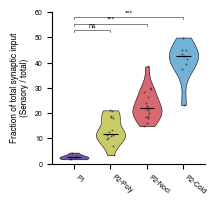


subtype      n  median %       vs P1
P1           6       2.6           -
P2-Poly     15      11.7       0.072
P2-Noci     16      22.1    0.000411
P2-Cold      9      42.5    6.62e-07


In [19]:
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import kruskal

SUBTYPES = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR", "C-HTMR-Non-peptidergic",
            "C-LTMR", "Aδ-LTMR", "Aβ-LTMR"]
SENSORY_COLUMNS = SUBTYPES + ["low_confidence_sensory"]

n_sensory = pn[SENSORY_COLUMNS].sum(axis=1)
pn["sensory_percent"] = 100 * n_sensory / (n_sensory + pn["N/A"])

H, p = kruskal(*[pn.loc[pn.subtype == s, "sensory_percent"].to_numpy()
                 for s in SUBTYPE_ORDER])
print(f"Kruskal-Wallis: H = {H:.4g}, p = {p:.4g}")
dunn = sp.posthoc_dunn(pn, val_col="sensory_percent", group_col="subtype",
                       p_adjust="holm")

fig, ax = plt.subplots(figsize=(5 * CM, 5 * CM))
data = [pn.loc[pn.subtype == s, "sensory_percent"].to_numpy() for s in SUBTYPE_ORDER]
parts = ax.violinplot(data, positions=np.arange(len(SUBTYPE_ORDER)), widths=0.8,
                      showmeans=False, showmedians=True, showextrema=False)
for body, s in zip(parts["bodies"], SUBTYPE_ORDER):
    body.set_facecolor(SUBTYPE_COLOURS[s]); body.set_edgecolor("black")
    body.set_linewidth(0.4); body.set_alpha(0.95)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(0.8)

rng = np.random.default_rng(0)
for i, vals in enumerate(data):
    ax.scatter(i + rng.uniform(-0.1, 0.1, len(vals)), vals,
               s=2, color="black", alpha=0.5, linewidths=0, zorder=3)

Y_MAX = 60
levels = np.linspace(max(v.max() for v in data) + 3, Y_MAX - 2, len(SUBTYPE_ORDER) - 1)
for k, (s, yy) in enumerate(zip(SUBTYPE_ORDER[1:], levels), start=1):
    pv = dunn.loc["P1", s]
    stars = "***" if pv < 1e-3 else "**" if pv < 1e-2 else "*" if pv < 0.05 else "ns"
    ax.plot([0, 0, k, k], [yy - 0.8, yy, yy, yy - 0.8], lw=0.5, color="0.3")
    ax.text(k / 2, yy, stars, ha="center", va="bottom", fontsize=5)

ax.set_ylim(0, Y_MAX)
ax.set_yticks(range(0, 61, 10))
ax.set_xticks(np.arange(len(SUBTYPE_ORDER)))
ax.set_xticklabels(SUBTYPE_ORDER, rotation=-40, ha="left", fontsize=5)
ax.set_ylabel("Fraction of total synaptic input\n(Sensory / total)", fontsize=6)
ax.tick_params(axis="y", labelsize=5)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.savefig("figure3b_pn_sensory_fraction_violin.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"\n{'subtype':10s}{'n':>4s}{'median %':>10s}{'vs P1':>12s}")
for s in SUBTYPE_ORDER:
    v = pn.loc[pn.subtype == s, "sensory_percent"]
    pv = "-" if s == "P1" else f"{dunn.loc['P1', s]:.3g}"
    print(f"{s:10s}{len(v):4d}{v.median():10.1f}{pv:>12s}")


## Figure 3d and S3f — per-PN sensory composition

Rows are individual PNs grouped by subtype with red dashed separators; within a group they
keep their order in the source table. **3d** shows each afferent's share of the neuron's
sensory synapses; **S3f** shows the same as raw counts on a log scale.

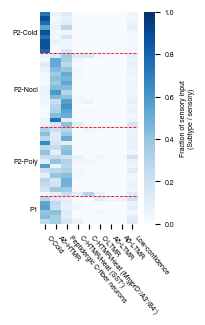

In [20]:
import seaborn as sns
from matplotlib.colors import LogNorm

DISPLAY = {"C-Heat": "Peptidergic C-fiber neurons",
           "C-HTMR": "C-HTMR/Heat (SST⁺)",
           "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprD⁺/A3⁺/B4⁺)",
           "low_confidence_sensory": "Low-confidence"}
COLUMN_ORDER = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR", "C-HTMR-Non-peptidergic",
                "C-LTMR", "Aδ-LTMR", "Aβ-LTMR", "low_confidence_sensory"]


def pn_heatmap(values, cbar_label, out_svg, norm=None, vmin=0, vmax=1):
    blocks = [values[pn.subtype == s] for s in HEATMAP_ORDER]
    ordered = pd.concat(blocks)
    sizes = [len(b) for b in blocks]

    fig = plt.figure(figsize=(5 * CM, 7 * CM))
    grid = fig.add_gridspec(1, 2, width_ratios=[2.4, 10], wspace=0.0)

    ax_lab = fig.add_subplot(grid[0, 0])
    ax_lab.set_xlim(0, 1); ax_lab.set_ylim(0, len(ordered))
    ax_lab.invert_yaxis(); ax_lab.axis("off")
    start = 0
    for s, n in zip(HEATMAP_ORDER, sizes):
        ax_lab.text(0.95, start + n / 2, s, va="center", ha="right", fontsize=5)
        start += n

    ax = fig.add_subplot(grid[0, 1])
    kw = {"norm": norm} if norm is not None else {"vmin": vmin, "vmax": vmax}
    sns.heatmap(ordered, cmap="Blues", ax=ax, yticklabels=False, xticklabels=True,
                rasterized=True, cbar_kws={"label": cbar_label}, **kw)
    for b in np.cumsum(sizes)[:-1]:
        ax.hlines(y=b, xmin=0, xmax=ordered.shape[1], colors="red",
                  linestyles="--", linewidth=0.6)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=5, rotation=-50, ha="left")
    ax.set_ylabel("")
    cb = ax.collections[0].colorbar
    cb.ax.tick_params(labelsize=5); cb.set_label(cbar_label, fontsize=5)

    fig.savefig(out_svg, format="svg", bbox_inches="tight", dpi=600)
    plt.show()


raw = pn[COLUMN_ORDER].copy()
raw.columns = [DISPLAY.get(c, c) for c in COLUMN_ORDER]

frac = raw.div(raw.sum(axis=1), axis=0).fillna(0)
pn_heatmap(frac, "Fraction of sensory input\n(Subtype / sensory)",
           "figure3d_pn_sensory_fraction_heatmap.svg")


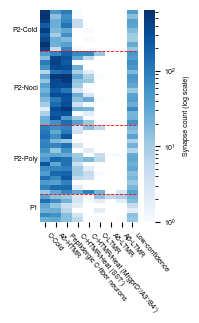

In [21]:
# S3f: the same rows as raw counts, log-scaled
pn_heatmap(raw.replace(0, np.nan), "Synapse count (log scale)",
           "figureS3f_pn_sensory_raw_counts_heatmap.svg",
           norm=LogNorm(vmin=1, vmax=max(raw.to_numpy().max(), 2)))


## Figure 3c — tri-axis scatter

Each PN placed by its absolute synapse counts from the three afferent classes that reach
PNs — C-Cold, Aδ-HTMR and peptidergic C-fibres — on three axes at 120°. Unlike panel 3d
this uses counts, not fractions, so it shows how *much* drive each subtype receives, which
is what separates P1 (almost none) from the P2 groups.

Ported from `three_axis_plot.ipynb`, repointed at the repository's data and at the
clustering computed above.

Cluster id -> group name: {np.int64(0): 'P2-Cold', np.int64(1): 'P2-Noci', np.int64(2): 'P2-Poly'} (-1 -> Other/noise)
Saved figure to figure3c_pn_three_axis.svg


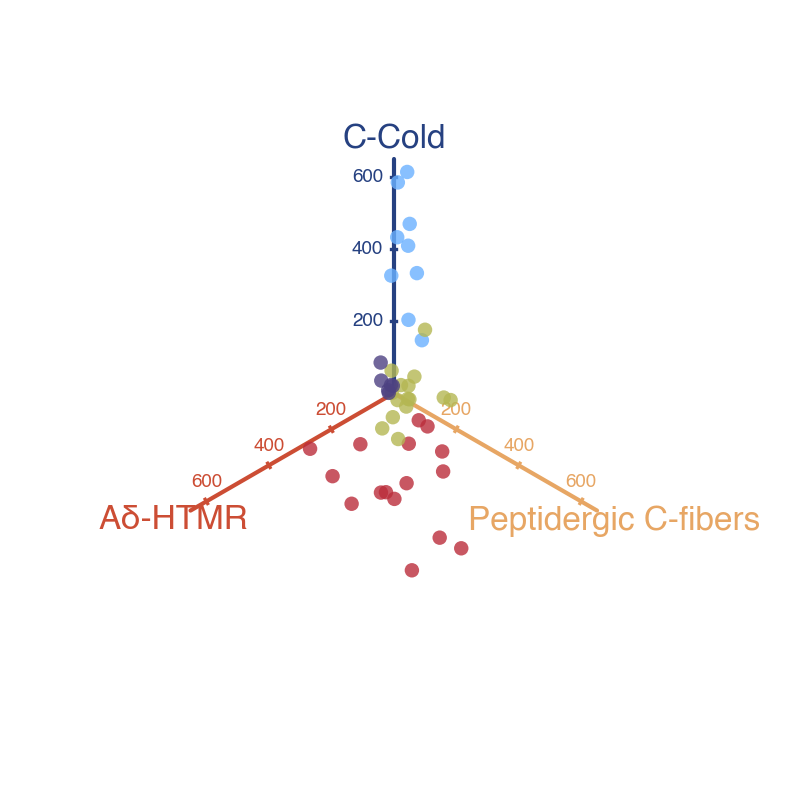

In [22]:
"""
Tri-axis (120 deg) scatter, colored by your ALREADY-COMPUTED HDBSCAN
clustering (loaded from the CSV you saved with save_cl_hdb.py) instead of
recomputing UMAP+HDBSCAN. No umap-learn / hdbscan install needed to run
this -- just pandas / numpy / matplotlib.

Inputs:
  SENSORY_CSV_PATH  -> your projection_neuron.csv (raw synapse counts +
                       'cell_type' column with p1/p2_poly/p2_noci/p2_cold)
  CLUSTER_CSV_PATH  -> the CSV save_cl_hdb.py wrote: index = neuron_id,
                       one column 'hdbscan_cluster' with the numeric
                       cluster id HDBSCAN assigned each P2 neuron (-1 = noise)

Cluster id -> group name (P2-Cold/P2-Noci/P2-Poly) is derived automatically
by majority vote against each cluster's true 'cell_type' labels, rather
than hardcoded, since HDBSCAN's numeric IDs aren't guaranteed to land in
any particular order.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ========= PARAMETERS =========
SENSORY_CSV_PATH = SENSORY_CSV
CLUSTER_CSV_PATH = REFERENCE_CLUSTERS

DROP_NOISE = False   # True = drop HDBSCAN noise (-1) points instead of showing them as "Other"

# ---- figure size, in cm ----
FIG_WIDTH_CM, FIG_HEIGHT_CM = 8.0, 8.0

# ---- optional: save the figure as SVG. Set a path to enable, leave as None to skip ----
SAVE_SVG_PATH = "figure3c_pn_three_axis.svg"   # e.g. "figure3c_pn_three_axis.svg"

dot_size, point_alpha = 12, 0.8
label_fs, tick_fs = 8, 4.5
axis_len, line_width = 1.2, 1
robust_pct, radial_fill = 95, 0.9
n_ticks, tick_len, tick_label_gap = 4, 0.025, 0.055

axis_colors = {
    'C-Cold': '#264181', 'Aδ-HTMR': '#cc4d34', 'Peptidergic C-fibers': '#e7a664',
}
color_map = {
    "P2-Cold": "#6ab1ff", "P2-Noci": "#bb2d3b", "P2-Poly": "#b4b753",
    "P1": "#4d4182", "Other": "#B0B0B0",
}
tick_label_offset_dir = {
    'C-Cold': np.array([-1.0, 0.0]),
    'Aδ-HTMR': np.array([0.0, 1.0]),
    'Peptidergic C-fibers': np.array([0.0, 1.0]),
}
tick_label_align = {
    'C-Cold': dict(ha='right', va='center'),
    'Aδ-HTMR': dict(ha='center', va='bottom'),
    'Peptidergic C-fibers': dict(ha='center', va='bottom'),
}
name_lookup = {"p2_cold": "P2-Cold", "p2_noci": "P2-Noci", "p2_poly": "P2-Poly"}

# ========= 1) LOAD =========
sens = pd.read_csv(SENSORY_CSV_PATH, index_col=0)
sens.index = sens.index.astype(str)
sens.columns = [c.strip() for c in sens.columns]

cl_hdb = pd.read_csv(CLUSTER_CSV_PATH, index_col=0)["hdbscan_cluster"]
cl_hdb.index = cl_hdb.index.astype(str)

# ========= 2) NAME each cluster id by majority vote against true cell_type =========
cid_to_name = {}
for cid in sorted(cl_hdb.unique()):
    if cid == -1:
        continue
    members = sens.loc[cl_hdb[cl_hdb == cid].index, "cell_type"].astype(str)
    majority = members.value_counts().idxmax()
    cid_to_name[cid] = name_lookup.get(majority, majority)
print("Cluster id -> group name:", cid_to_name, "(-1 -> Other/noise)")

p2_group = cl_hdb.map(cid_to_name).fillna("Other")
if DROP_NOISE:
    p2_group = p2_group[p2_group != "Other"]

# ========= 3) BUILD plot_df: P2 (HDBSCAN-labeled) + P1 (from CSV) =========
p2_df = sens.loc[p2_group.index].copy()
p2_df["group"] = p2_group

p1_df = sens[sens["cell_type"].astype(str) == "p1"].copy()
p1_df["group"] = "P1"

plot_df = pd.concat([p2_df, p1_df], axis=0)
group_order = ["P2-Cold", "P2-Noci", "P2-Poly", "P1"] + ([] if DROP_NOISE else ["Other"])

# ========= 4) GEOMETRY & PROJECTION (raw synapse counts -> tri-axis position) =========
cols = ['C-Cold', 'Aδ-HTMR', 'C-Heat']   # C-Heat is drawn/labeled as "Peptidergic C-Nociceptor"
for c in cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce").fillna(0.0)

def polar(deg, r=1.0):
    a = np.deg2rad(deg)
    return np.array([np.cos(a) * r, np.sin(a) * r])

vC, vA, vP = polar(90), polar(210), polar(330)
B = np.vstack([vC, vA, vP])

vals = plot_df[cols].to_numpy(float)
scale_val = max(1.0, float(np.percentile(vals, robust_pct)) if vals.size else 1.0)
XY0 = (vals / scale_val) @ B
r = np.linalg.norm(XY0, axis=1)
r99 = max(1e-6, float(np.percentile(r, robust_pct)) if r.size else 1.0)
XY = XY0 / r99 * radial_fill
plot_df["_x"], plot_df["_y"] = XY[:, 0], XY[:, 1]
k = radial_fill / (scale_val * r99)   # raw count -> plotted radius, same factor for all 3 axes

def nice_ticks(max_val, n=4):
    if max_val <= 0:
        return np.array([0])
    raw_step = max_val / n
    mag = 10 ** np.floor(np.log10(raw_step))
    for m in (1, 2, 2.5, 5, 10):
        if m * mag >= raw_step:
            return np.arange(m * mag, max_val + m * mag / 2, m * mag)
    return np.arange(10 * mag, max_val + 10 * mag / 2, 10 * mag)

tick_vals = nice_ticks(axis_len / k, n_ticks)

# ========= 5) PLOT =========
cm_to_in = 1 / 2.54
fig, ax = plt.subplots(figsize=(FIG_WIDTH_CM * cm_to_in, FIG_HEIGHT_CM * cm_to_in), dpi=300)
origin = np.array([0.0, 0.0])
axis_specs = [(vC, "C-Cold", 90), (vA, "Aδ-HTMR", 210), (vP, "Peptidergic C-fibers", 330)]

for unit_vec, label, ang in axis_specs:
    vec = unit_vec * axis_len
    color = axis_colors.get(label, "black")
    ax.plot([origin[0], origin[0] + vec[0]], [origin[1], origin[1] + vec[1]],
             lw=line_width, color=color, solid_capstyle="round", zorder=2)
    ax.text(*(origin + vec + polar(ang, 0.10)), label, ha="center", va="center",
            fontsize=label_fs, color=color, zorder=4)

    perp = np.array([-unit_vec[1], unit_vec[0]])
    label_dir, align = tick_label_offset_dir[label], tick_label_align[label]
    for t in tick_vals:
        pos = origin + unit_vec * (t * k)
        a, b = pos - perp * (tick_len / 2), pos + perp * (tick_len / 2)
        ax.plot([a[0], b[0]], [a[1], b[1]], lw=line_width * 0.8, color=color, zorder=3)
        ax.text(*(pos + label_dir * tick_label_gap), f"{t:g}",
                fontsize=tick_fs, color=color, zorder=4, **align)

for g in group_order:
    sub = plot_df[plot_df["group"] == g]
    if sub.empty:
        continue
    ax.scatter(sub["_x"], sub["_y"], s=dot_size, marker="o",
               facecolors=color_map.get(g, "#666666"), edgecolors="none",
               linewidths=0, alpha=point_alpha, zorder=5)

pad = axis_len * 1.55
ax.set_xlim(-pad, pad)
ax.set_ylim(-pad, pad)
ax.set_aspect("equal", adjustable="box")
ax.axis("off")

if SAVE_SVG_PATH:
    Path(SAVE_SVG_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_SVG_PATH, format="svg", bbox_inches="tight", pad_inches=0.02)
    print("Saved figure to", SAVE_SVG_PATH)

plt.show()